<a href="https://colab.research.google.com/github/fa-elma/Wine_Quality_prediction/blob/main/Wine_Quality_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ==========================================
# 1. Necessary Libraries Import
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========================================
# 2. Direct Data Loading (UCI Official Repository)
# ==========================================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

# Data Cleaning
df.drop_duplicates(inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# Target column conversion: Quality >= 6 means Good (1), else Bad (0)
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 6 else 0)

# ==========================================
# 3. Train-Test Split & Scaling
# ==========================================
X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 4. Model Training & Evaluation
# ==========================================
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, predictions)
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, predictions))
    print("-" * 40)

=== Logistic Regression ===
Accuracy: 0.7353
              precision    recall  f1-score   support

           0       0.71      0.74      0.73       128
           1       0.76      0.73      0.74       144

    accuracy                           0.74       272
   macro avg       0.73      0.74      0.73       272
weighted avg       0.74      0.74      0.74       272

----------------------------------------
=== Decision Tree ===
Accuracy: 0.6250
              precision    recall  f1-score   support

           0       0.60      0.59      0.60       128
           1       0.64      0.66      0.65       144

    accuracy                           0.62       272
   macro avg       0.62      0.62      0.62       272
weighted avg       0.62      0.62      0.62       272

----------------------------------------
=== Random Forest ===
Accuracy: 0.7684
              precision    recall  f1-score   support

           0       0.74      0.79      0.76       128
           1       0.80      0.7

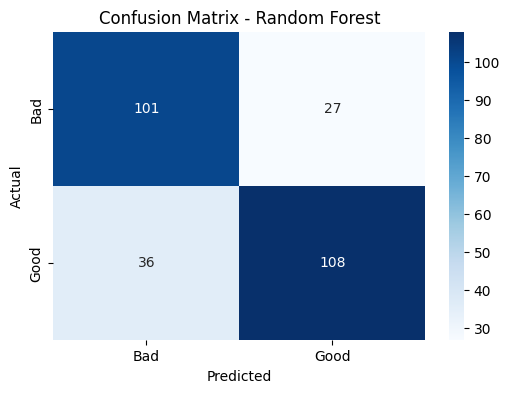

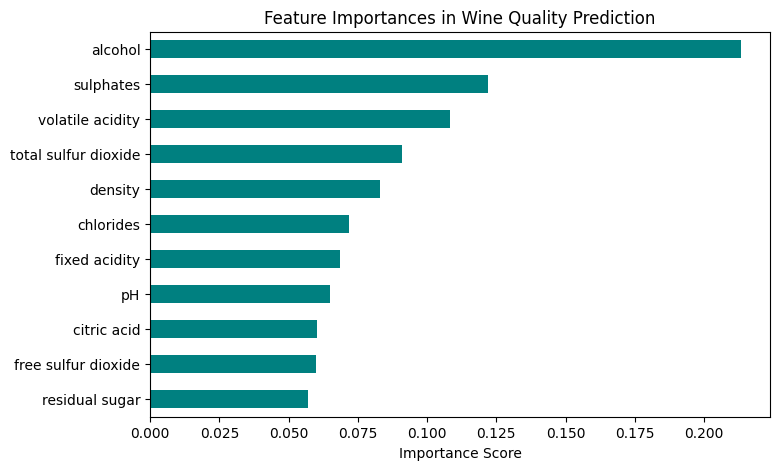

In [3]:
# ==========================================
# 5. Visualizations (Confusion Matrix & Feature Importance)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Confusion Matrix for Random Forest
rf_model = models['Random Forest']
rf_preds = rf_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

# 2. Feature Importance Plot
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='teal')
plt.title('Feature Importances in Wine Quality Prediction')
plt.xlabel('Importance Score')
plt.show()

In [4]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv -O winequality-red.csv

--2026-08-31 17:43:49--  https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘winequality-red.csv’

winequality-red.csv     [  <=>               ]  82.23K   320KB/s    in 0.3s    

2026-08-31 17:43:50 (320 KB/s) - ‘winequality-red.csv’ saved [84199]



In [5]:
# ==========================================
# 1. Necessary Libraries Import
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========================================
# 2. Data Loading & Preprocessing (Local File)
# ==========================================
# Reading local csv file uploaded/saved in Colab
df = pd.read_csv('winequality-red.csv', sep=';')

# Data Cleaning
df.drop_duplicates(inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# Target column conversion: Quality >= 6 means Good (1), else Bad (0)
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 6 else 0)

# ==========================================
# 3. Train-Test Split & Scaling
# ==========================================
X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 4. Model Training & Evaluation
# ==========================================
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, predictions)
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, predictions))
    print("-" * 40)

=== Logistic Regression ===
Accuracy: 0.7353
              precision    recall  f1-score   support

           0       0.71      0.74      0.73       128
           1       0.76      0.73      0.74       144

    accuracy                           0.74       272
   macro avg       0.73      0.74      0.73       272
weighted avg       0.74      0.74      0.74       272

----------------------------------------
=== Decision Tree ===
Accuracy: 0.6250
              precision    recall  f1-score   support

           0       0.60      0.59      0.60       128
           1       0.64      0.66      0.65       144

    accuracy                           0.62       272
   macro avg       0.62      0.62      0.62       272
weighted avg       0.62      0.62      0.62       272

----------------------------------------
=== Random Forest ===
Accuracy: 0.7684
              precision    recall  f1-score   support

           0       0.74      0.79      0.76       128
           1       0.80      0.7